# Proyecto 1 
 Juan Camilo Gómez-202220238
 
 Jerónimo Rueda-202223775

### Librerias


In [93]:
   
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns  

## Datos

In [94]:
df = pd.read_csv("Saber 11 Datos Valle.csv")


mapaarreglo = {
    "Sin Estrato": 0,
    "Estrato 1": 1,
    "Estrato 2": 2,
    "Estrato 3": 3,
    "Estrato 4": 4,
    "Estrato 5": 5,
    "Estrato 6": 6
}

df["estrato_num"] = df["fami_estratovivienda"].map(mapaarreglo)


#df[df["fami_estratovivienda"]=="Sin Estrato"][["estrato_num", "fami_estratovivienda"]].head()

df[df["punt_lectura_critica"].isna()]["periodo"].value_counts()

df=df[df["punt_global"].notna()]


### Atributos

In [95]:
df.shape
print(df["estrato_num"].value_counts())
print(df["fami_estratovivienda"].value_counts())

estrato_num
2.0    137505
1.0    105724
3.0     82248
4.0     21810
5.0     12203
6.0      5415
0.0      4283
Name: count, dtype: int64
fami_estratovivienda
Estrato 2      137505
Estrato 1      105724
Estrato 3       82248
Estrato 4       21810
Estrato 5       12203
Estrato 6        5415
Sin Estrato      4283
Name: count, dtype: int64


# Descripción Breve Estadística

In [96]:
df.describe()

,periodo,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,cole_cod_mcpio_ubicacion,cole_codigo_icfes,estu_cod_depto_presentacion,estu_cod_mcpio_presentacion,estu_cod_reside_depto,estu_cod_reside_mcpio,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,estrato_num
count,387831.000000,3.876690e+05,3.878310e+05,387831.0,387831.000000,387831.000000,387803.000000,387803.000000,387555.000000,387555.000000,387717.000000,387831.000000,387831.000000,387831.000000,387831.00000,387831.000000,369188.000000
mean,20182.692152,2.587149e+11,2.594622e+11,76.0,76203.549647,161954.670176,75.803011,75999.157621,75.795952,75997.864907,51.179440,50.697319,49.525677,50.481117,52.96090,254.682014,2.189191
std,28.168233,9.688064e+10,9.704902e+10,0.0,288.239776,207667.431000,3.393343,3405.135008,3.439208,3447.667817,12.655051,11.897492,11.774947,10.738144,10.31491,50.461819,1.135001
min,20142.000000,1.760010e+11,1.760010e+11,76.0,76001.000000,16659.000000,5.000000,5001.000000,5.000000,5001.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,20161.000000,1.761090e+11,1.761090e+11,76.0,76001.000000,28936.000000,76.000000,76001.000000,76.000000,76001.000000,42.000000,42.000000,41.000000,43.000000,46.00000,217.000000,1.000000
50%,20181.000000,1.768340e+11,1.768340e+11,76.0,76001.000000,100461.000000,76.000000,76001.000000,76.000000,76001.000000,49.000000,50.000000,49.000000,50.000000,53.00000,252.000000,2.000000
75%,20201.000000,3.760010e+11,3.760010e+11,76.0,76364.000000,152439.000000,76.000000,76318.000000,76.000000,76364.000000,58.000000,58.000000,58.000000,58.000000,60.00000,289.000000,3.000000
max,20224.000000,5.376109e+11,5.376110e+11,76.0,76895.000000,806752.000000,99.000000,99524.000000,97.000000,97161.000000,100.000000,100.000000,100.000000,100.000000,100.00000,495.000000,6.000000


In [97]:
df.info()
colegios=df.groupby("cole_cod_dane_sede").describe()


<class 'pandas.core.frame.DataFrame'>
Index: 387831 entries, 0 to 642590
Data columns (total 52 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   periodo                        387831 non-null  int64  
 1   estu_tipodocumento             387831 non-null  object 
 2   estu_consecutivo               387831 non-null  object 
 3   cole_area_ubicacion            387826 non-null  object 
 4   cole_bilingue                  344641 non-null  object 
 5   cole_calendario                387831 non-null  object 
 6   cole_caracter                  380025 non-null  object 
 7   cole_cod_dane_establecimiento  387669 non-null  float64
 8   cole_cod_dane_sede             387831 non-null  float64
 9   cole_cod_depto_ubicacion       387831 non-null  int64  
 10  cole_cod_mcpio_ubicacion       387831 non-null  int64  
 11  cole_codigo_icfes              387831 non-null  float64
 12  cole_depto_ubicacion           3878

## Faltantes

In [148]:
df[["cole_cod_mcpio_ubicacion","estrato_num"]].groupby("cole_cod_mcpio_ubicacion").value_counts()
prom_estrato=(df.groupby("cole_cod_mcpio_ubicacion")["estrato_num"].transform("mean").round())

df["estrato_num"] = df["estrato_num"].fillna(prom_estrato).astype("Int64")
df["fami_estratovivienda"]=df["fami_estratovivienda"].fillna("Estrato"+prom_estrato.astype("string")).astype("string")

#print(prom_estrato)

#df[df["cole_bilingue"].isna()].describe()
#df[["cole_bilingue","estrato_num"]].groupby("cole_bilingue").value_counts()
df["cole_bilingue"] = df["cole_bilingue"].fillna("Desconocido")
df["cole_caracter"] = df["cole_caracter"].fillna("Desconocido")
df["cole_cod_dane_establecimiento"] = df["cole_cod_dane_establecimiento"].fillna("Desconocido (Instituto Tecnológico Gran Colombia)")
df["cole_area_ubicacion"] = df["cole_area_ubicacion"].fillna("RURAL")
df["cole_cod_dane_establecimiento"] = df["cole_area_ubicacion"].fillna("RURAL")
df["estu_cod_depto_presentacion"] = df["estu_cod_depto_presentacion"].fillna(df["estu_cod_reside_depto"])
df["estu_depto_presentacion"] = df["estu_depto_presentacion"].fillna(df["estu_depto_reside"])

df["estu_cod_mcpio_presentacion"] = df["estu_cod_mcpio_presentacion"].fillna(df["estu_cod_reside_mcpio"])
df["estu_cod_reside_depto"] = df["estu_cod_reside_depto"].fillna(df["cole_depto_ubicacion"])
df["estu_cod_reside_mcpio"] = df["estu_cod_reside_mcpio"].fillna(df["cole_mcpio_ubicacion"])
df["estu_depto_reside"] = df["estu_depto_reside"].fillna(df["estu_depto_presentacion"])
df["estu_genero"] = df["estu_genero"].fillna("Desconocido")
df["estu_mcpio_presentacion"] = df["estu_mcpio_presentacion"].fillna(df["cole_mcpio_ubicacion"])
df["estu_mcpio_reside"] = df["estu_mcpio_reside"].fillna(df["cole_mcpio_ubicacion"])

df["fami_cuartoshogar"] = df["fami_cuartoshogar"].fillna("Desconocido")
df["fami_educacionmadre"] = df["fami_educacionmadre"].fillna("Desconocido")
df["fami_educacionpadre"] = df["fami_educacionpadre"].fillna("Desconocido")
df["fami_personashogar"] = df["fami_personashogar"].fillna("Desconocido")
df["fami_tieneautomovil"] = df["fami_tieneautomovil"].fillna("No")
df["fami_tienecomputador"] = df["fami_tienecomputador"].fillna("No")
df["fami_tieneinternet"] = df["fami_tieneinternet"].fillna(df["fami_tienecomputador"])
df["fami_tienelavadora"] = df["fami_tienelavadora"].fillna("No")




#df[df["cole_area_ubicacion"].isna()].head()
#df[["cole_cod_dane_establecimiento","cole_cod_mcpio_ubicacion"]]["cole_cod_dane_establecimiento"].isna().groupby(df["cole_cod_mcpio_ubicacion"]).value_counts()
#df[df["cole_cod_dane_establecimiento"].isna()]["cole_nombre_establecimiento"].value_counts()
df[df["desemp_ingles"].isna()]["estrato_num"].value_counts()
#df["fami_tienecomputador"].value_counts()

df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]
x=df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]+df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]
reemplazaringles=round((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_matematicas"]/x)*df["punt_matematicas"]+(df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_lectura_critica"]/x)*df["punt_lectura_critica"]+((df[["punt_ingles", "punt_matematicas", "punt_lectura_critica","punt_global"]].corr()["punt_ingles"]["punt_global"]/5)/x)*df["punt_global"],0)
#print(reemplazaringles

df["punt_ingles"] = df["punt_ingles"].fillna(reemplazaringles)


df[df["desemp_ingles"].isna()]["punt_ingles"].describe()



"""
if df["punt_ingles"]<27:

    df["desemp_ingles"]=df["desemp_ingles"].fillna("A1")

elif df["punt_ingles"]<=40:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("A2")
elif df["punt_ingles"]<55:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B1")
else:
    df["desemp_ingles"]=df["desemp_ingles"].fillna("B+")
"""

condiciones = [
    df["punt_ingles"] < 27,
    df["punt_ingles"] <= 40,
    df["punt_ingles"] < 55]
valores = ["A1", "A2", "B1"]
#df["desemp_ingles"].value_counts()

nivel_calc = np.select(condiciones, valores, default="B+")

# Solo llenar faltantes en desemp_ingles
df["desemp_ingles"] = df["desemp_ingles"].fillna(pd.Series(nivel_calc, index=df.index))

df.isna().sum()

periodo                          0
estu_tipodocumento               0
estu_consecutivo                 0
cole_area_ubicacion              0
cole_bilingue                    0
cole_calendario                  0
cole_caracter                    0
cole_cod_dane_establecimiento    0
cole_cod_dane_sede               0
cole_cod_depto_ubicacion         0
cole_cod_mcpio_ubicacion         0
cole_codigo_icfes                0
cole_depto_ubicacion             0
cole_genero                      0
cole_jornada                     0
cole_mcpio_ubicacion             0
cole_naturaleza                  0
cole_nombre_establecimiento      0
cole_nombre_sede                 0
cole_sede_principal              0
estu_cod_depto_presentacion      0
estu_cod_mcpio_presentacion      0
estu_cod_reside_depto            0
estu_cod_reside_mcpio            0
estu_depto_presentacion          0
estu_depto_reside                0
estu_estadoinvestigacion         0
estu_estudiante                  0
estu_fechanacimiento

## Columnas y Ejemplo

In [99]:
columnas=df.columns
for i in columnas:
    print(f"Columna:{i} , Ejemplo: {df[i][2]}")


Columna:periodo , Ejemplo: 20224
Columna:estu_tipodocumento , Ejemplo: TI
Columna:estu_consecutivo , Ejemplo: SB11202240151458
Columna:cole_area_ubicacion , Ejemplo: URBANO
Columna:cole_bilingue , Ejemplo: N
Columna:cole_calendario , Ejemplo: A
Columna:cole_caracter , Ejemplo: TÉCNICO/ACADÉMICO
Columna:cole_cod_dane_establecimiento , Ejemplo: URBANO
Columna:cole_cod_dane_sede , Ejemplo: 176364001313.0
Columna:cole_cod_depto_ubicacion , Ejemplo: 76
Columna:cole_cod_mcpio_ubicacion , Ejemplo: 76364
Columna:cole_codigo_icfes , Ejemplo: 671156.0
Columna:cole_depto_ubicacion , Ejemplo: VALLE
Columna:cole_genero , Ejemplo: MIXTO
Columna:cole_jornada , Ejemplo: UNICA
Columna:cole_mcpio_ubicacion , Ejemplo: JAMUNDÍ
Columna:cole_naturaleza , Ejemplo: OFICIAL
Columna:cole_nombre_establecimiento , Ejemplo: INSTITUCION EDUCATIVA TÉCNICA INDUSTRIAL ESPAÑA
Columna:cole_nombre_sede , Ejemplo: TÉCNICA INDUSTRIAL ESPAÑA-SEDE PRINCIPAL
Columna:cole_sede_principal , Ejemplo: S
Columna:estu_cod_depto_pres

# Gráficos de una Variable


### Puntajes

Hay algunas categorias que tienen datos que pasan 100 o son menores que 0

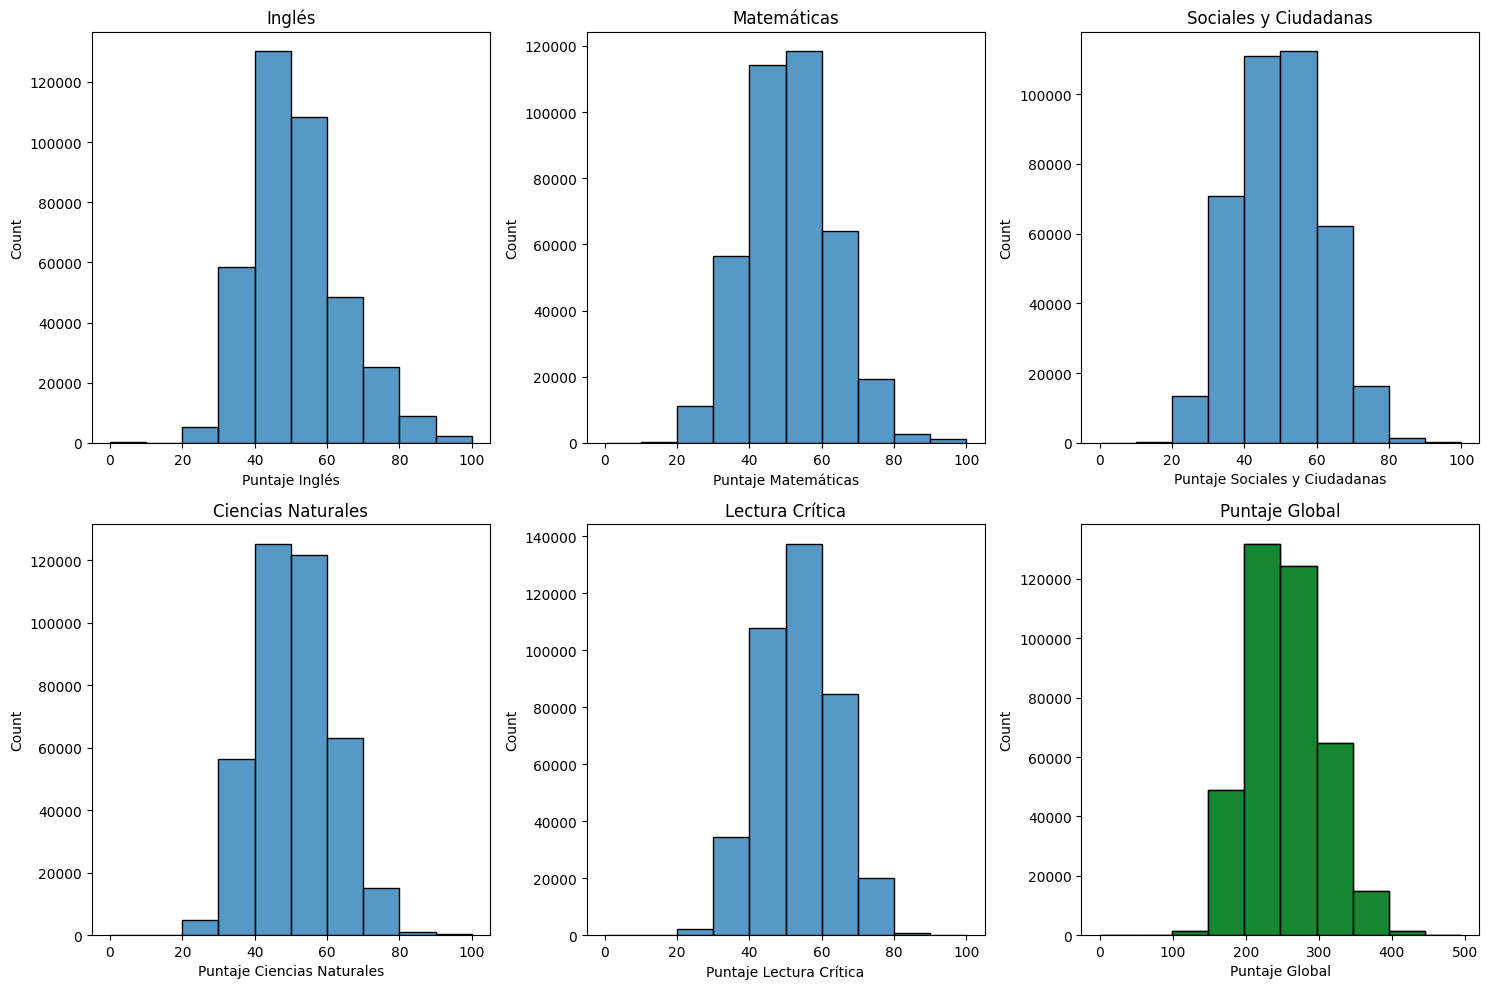

In [100]:
puntajes = ["punt_ingles","punt_matematicas","punt_sociales_ciudadanas","punt_c_naturales","punt_lectura_critica","punt_global"]

fig, axes = plt.subplots(2, 3, figsize=(15,10))
axes = axes.flatten()

for i in range(len(puntajes)):
    sns.histplot(df[puntajes[i]], bins=10, ax=axes[i])
    axes[i].set_title(puntajes[i])

axes[0].set_xlabel("Puntaje Inglés")
axes[0].set_title("Inglés")
axes[1].set_xlabel("Puntaje Matemáticas")
axes[1].set_title("Matemáticas")
axes[2].set_xlabel("Puntaje Sociales y Ciudadanas")
axes[2].set_title("Sociales y Ciudadanas")
axes[3].set_xlabel("Puntaje Ciencias Naturales")
axes[3].set_title("Ciencias Naturales")
axes[4].set_xlabel("Puntaje Lectura Crítica")
axes[4].set_title("Lectura Crítica")
axes[5].set_xlabel("Puntaje Global")
axes[5].set_title("Puntaje Global")

sns.histplot(df[puntajes[5]], bins=10, ax=axes[5], color="green")
plt.tight_layout()
plt.show()

### Distribución de Estratos


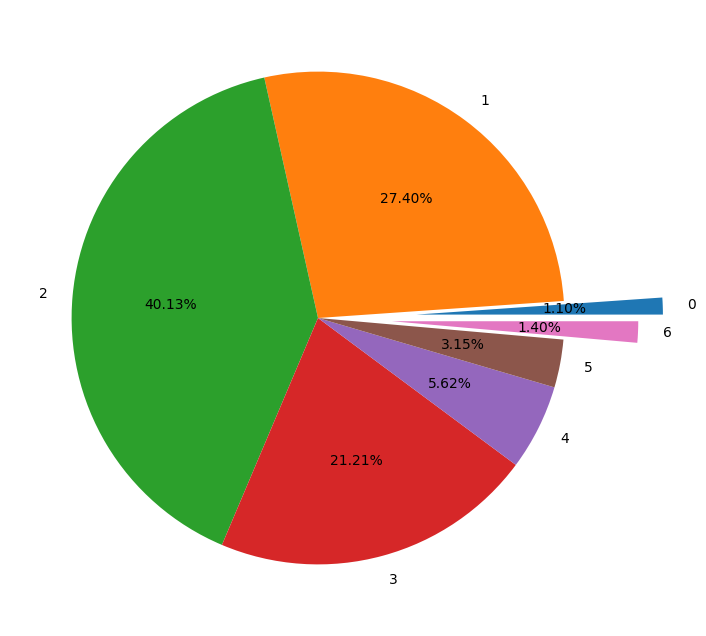

             Cantidad Porcentaje
estrato_num                     
0                4283    1.1043%
1              106249   27.3957%
2              155623   40.1265%
3               82248   21.2072%
4               21810    5.6236%
5               12203    3.1465%
6                5415    1.3962%


In [101]:
cuantas = df["estrato_num"].value_counts().sort_index().to_frame(name="Cantidad")

explode = (0.4, 0, 0, 0, 0, 0, 0.3)

cuantas["Porcentaje"] = (cuantas["Cantidad"] / cuantas["Cantidad"].sum() * 100).round(4).astype(str) + "%"

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(cuantas["Cantidad"], labels=cuantas.index, autopct="%.2f%%", explode=explode)
plt.show()

print(cuantas)

### Personas en el hogar

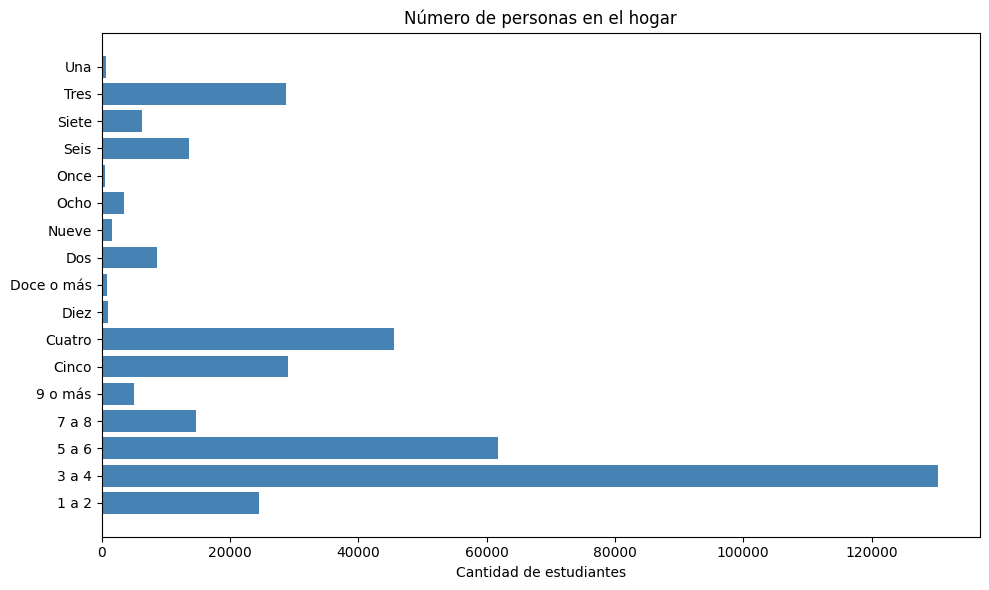

                    Personas Porcentaje
fami_personashogar                     
1 a 2                  24553    6.5228%
3 a 4                 130387   34.6389%
5 a 6                  61726   16.3983%
7 a 8                  14660    3.8946%
9 o más                 5108     1.357%
Cinco                  29077    7.7247%
Cuatro                 45572   12.1068%
Diez                    1050    0.2789%
Doce o más               784    0.2083%
Dos                     8625    2.2913%
Nueve                   1562     0.415%
Ocho                    3509    0.9322%
Once                     461    0.1225%
Seis                   13555     3.601%
Siete                   6278    1.6678%
Tres                   28776    7.6447%
Una                      735    0.1953%


In [102]:
fig, ax = plt.subplots(figsize=(10,6))

personas = df["fami_personashogar"].value_counts().sort_index().to_frame(name="Personas")
personas["Porcentaje"] = (personas["Personas"] / personas["Personas"].sum() * 100).round(4).astype(str) + "%"
labels = personas.index
valores = personas["Personas"]

bar_pos = range(len(labels))

ax.barh(bar_pos, valores, color="steelblue")

ax.set_yticks(bar_pos, labels)
ax.set_xlabel("Cantidad de estudiantes")
ax.set_title("Número de personas en el hogar")

plt.tight_layout()
plt.show()

print(personas)

### Presentaron en un departamento diferente al Valle


In [103]:

df[df["estu_cod_depto_presentacion"]!=76]
df[df["estu_depto_presentacion"]!="VALLE"] 

df[df["estu_cod_depto_presentacion"]!=76]["estu_depto_presentacion"].value_counts()


estu_depto_presentacion
RISARALDA          325
BOGOTÁ             296
CAUCA              231
CALDAS             182
ANTIOQUIA          179
CASANARE           149
CUNDINAMARCA       107
QUINDIO             91
TOLIMA              72
NARIÑO              52
META                50
SANTANDER           42
HUILA               39
BOYACA              28
ATLANTICO           26
CAQUETA             26
SAN ANDRES          20
BOLIVAR             17
CHOCO               15
CESAR               12
ARAUCA              11
VICHADA             11
PUTUMAYO            10
MAGDALENA           10
SUCRE                7
CORDOBA              5
NORTE SANTANDER      4
GUAVIARE             2
LA GUAJIRA           2
Name: count, dtype: int64

### Viven en un departamento diferente al Valle

In [104]:


df[df["estu_cod_reside_depto"]!=76]

df[df["estu_depto_reside"]!="VALLE"]["estu_depto_reside"].value_counts()



estu_depto_reside
CAUCA              407
BOGOTÁ             298
CALDAS             266
RISARALDA          130
CUNDINAMARCA        93
ANTIOQUIA           76
NARIÑO              54
QUINDIO             43
SANTANDER           40
ATLANTICO           26
TOLIMA              24
CHOCO               23
BOYACA              20
HUILA               17
BOLIVAR             15
CASANARE            12
CESAR               10
MAGDALENA           10
META                10
PUTUMAYO            10
CAQUETA              6
CORDOBA              4
NORTE SANTANDER      4
GUAVIARE             2
SUCRE                2
SAN ANDRES           1
AMAZONAS             1
VAUPES               1
Name: count, dtype: int64

### Nacionalidades

In [105]:
df["estu_nacionalidad"].value_counts()





estu_nacionalidad
COLOMBIA                  386246
VENEZUELA                   1213
ESTADOS UNIDOS                95
ESPAÑA                        75
ECUADOR                       52
ITALIA                        14
FRANCIA                       13
COSTA RICA                    10
MÉXICO                        10
PERÚ                           9
CUBA                           8
REINO UNIDO                    8
ARGENTINA                      8
NICARAGUA                      6
CHILE                          5
BRASIL                         5
PAÍSES BAJOS - HOLANDA         4
VANUATU                        4
ARUBA                          4
JAPÓN                          4
COMORAS                        3
PANAMÁ                         3
HONDURAS                       3
GUATEMALA                      2
OMÁN                           2
PORTUGAL                       2
AUSTRALIA                      2
CURAZAO                        2
CANADÁ                         2
BRUNÉI                   

Todos viven en el mismo pais en que residen

In [106]:
df[df["estu_nacionalidad"]!=df["estu_pais_reside"]]

,periodo,estu_tipodocumento,estu_consecutivo,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_cod_dane_establecimiento,cole_cod_dane_sede,cole_cod_depto_ubicacion,...,fami_tieneinternet,fami_tienelavadora,desemp_ingles,punt_ingles,punt_matematicas,punt_sociales_ciudadanas,punt_c_naturales,punt_lectura_critica,punt_global,estrato_num


In [107]:
df[df["estu_nacionalidad"]!="COLOMBIA"]["estu_depto_reside"].value_counts()




estu_depto_reside
VALLE      1584
BOLIVAR       1
Name: count, dtype: int64